# Visualization

Trong bài tập này, bạn sẽ được rèn luyện kĩ năng trực quan hóa. Trực quan hóa ngoài việc hỗ  trợ trong khâu tiền xử lí dữ liệu, còn giúp bạn phân tích và rút ra được các thông tin có ý nghĩa từ dữ liệu

**Tập dữ liệu** được sử dụng được lấy từ trang batdongsan.com.vn

In [1]:
#Import các thư viện cần thiết

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [2]:
#Load dữ liệu từ file
newdf = pd.read_csv("batdongsan.com.vn.csv", dtype = {"month": "string" , "id" : "string"})
print("DONE")

DONE


In [3]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='object')

In [4]:
# Xem 5 hàng dữ liệu đầu tiên, các thông tin ban đầu: df.info(), df.describe(), ...
# Code ở đây:
newdf.head()
newdf.info()
newdf.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  string 
 1   month      81162 non-null  string 
 2   project    78097 non-null  object 
 3   investor   65453 non-null  object 
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  object 
 8   balcony    54426 non-null  object 
 9   district   81162 non-null  object 
 10  ward       79506 non-null  object 
 11  price      81162 non-null  float64
dtypes: float64(4), object(6), string(2)
memory usage: 7.4+ MB


,square,bedrooms,bathrooms,price
count,81162.000000,81162.000000,81162.000000,81162.000000
mean,83.481974,2.365602,1.897785,2404.748090
std,25.662160,0.622283,0.404293,1038.825418
min,7.000000,1.000000,1.000000,350.000000
25%,66.000000,2.000000,2.000000,1520.000000
50%,79.000000,2.000000,2.000000,2300.000000
75%,98.000000,3.000000,2.000000,3150.000000
max,296.000000,4.000000,4.000000,5000.000000


Đưa ra các câu lệnh để thực hiện các yêu cầu sau:

1. Minh họa boxblot của các trường số như price, bedrooms, square, ...

* Gợi ý: sns.boxplot(data_field)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


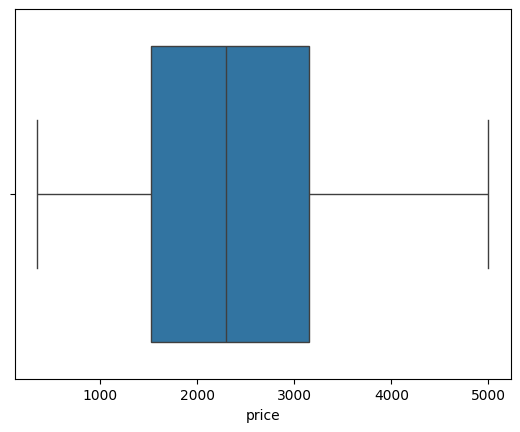

In [5]:
#Code for 'price' field
sns.boxplot(x = newdf["price"])
plt.show()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


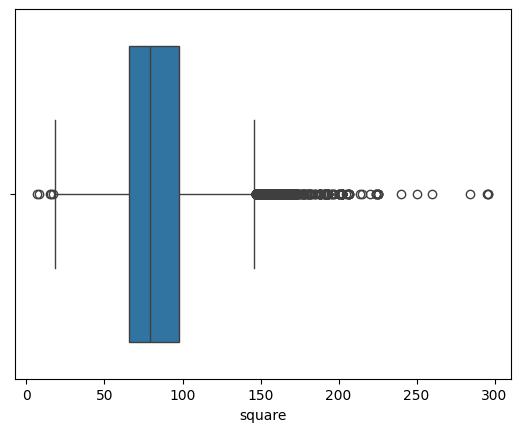

In [6]:
#Code for 'square' field
sns.boxplot(x = newdf["square"])
plt.show()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


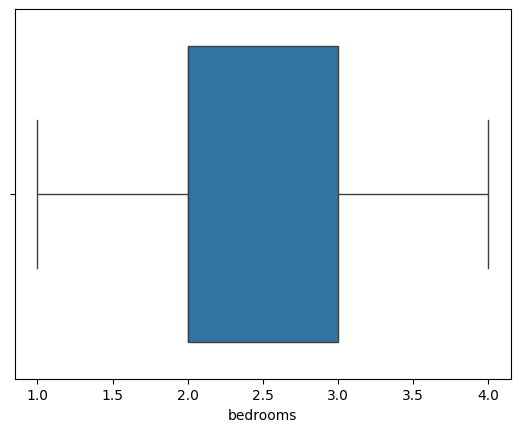

In [7]:
#Code for 'bedrooms' field
sns.boxplot(x = newdf["bedrooms"])
plt.show()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


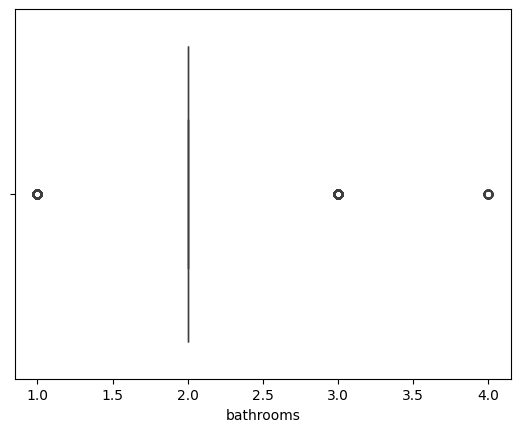

In [8]:
#Code for 'bathrooms' field
sns.boxplot(x = newdf["bathrooms"])
plt.show()

2. Cho đoạn code minh họa Biểu đồ thể hiện số bài đăng theo tháng của năm 2020. Hãy thực hiện các yêu cầu cho các câu hỏi dưới đây:

C:\Users\Admin\AppData\Local\Temp\ipykernel_10552\1920162332.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')


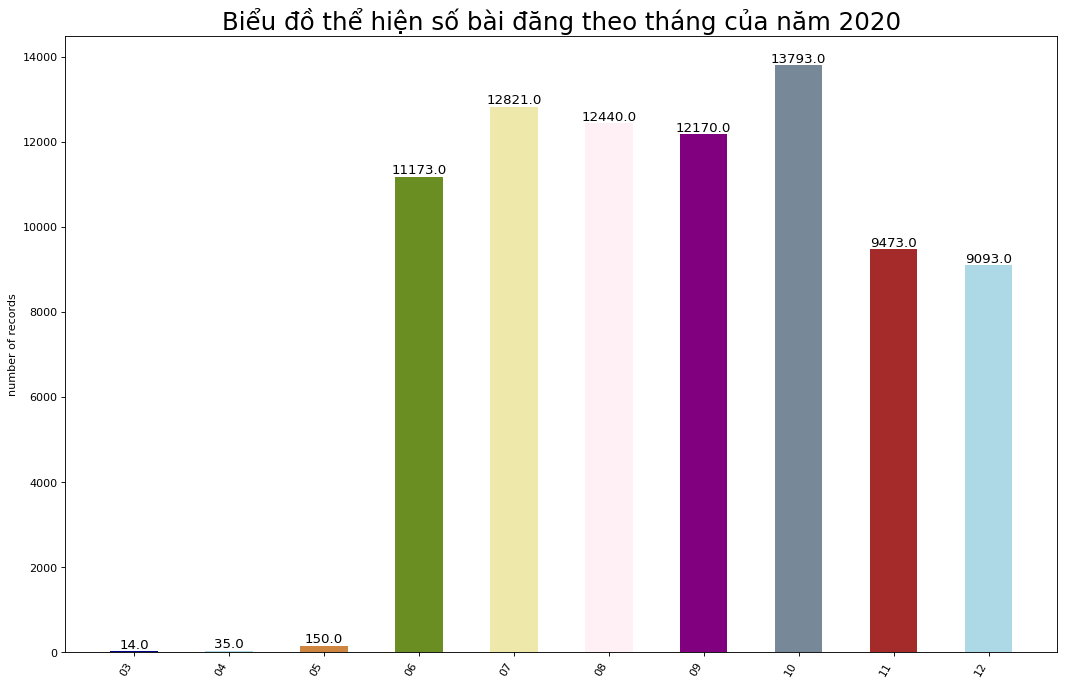

In [9]:
df1 = newdf.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

* Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10552\3090326041.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df_price_month['month'], rotation=60, horizontalalignment='right')


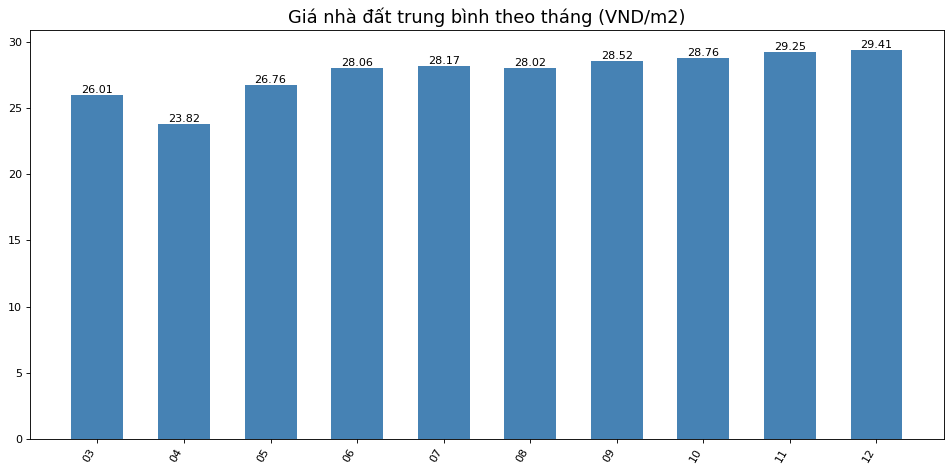

In [10]:
def average_price(x):
    return x['price'] / x['square']
dftmp = newdf.copy()
dftmp['pricePerSquare'] = dftmp.apply(average_price, axis=1)
df_price_month = dftmp.groupby('month')['pricePerSquare'].mean().reset_index(name='price')
plt.figure(figsize=(12, 6), dpi=80)
plt.bar(df_price_month['month'], df_price_month['price'], color='steelblue', width=.6)
for i, val in enumerate(df_price_month['price'].values):
    plt.text(i, val, f'{val:.2f}', horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':10})
plt.gca().set_xticklabels(df_price_month['month'], rotation=60, horizontalalignment='right')
plt.title("Giá nhà đất trung bình theo tháng (VND/m2)", fontsize=16)
plt.tight_layout()
plt.show()

* Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)

<Figure size 1040x800 with 0 Axes>

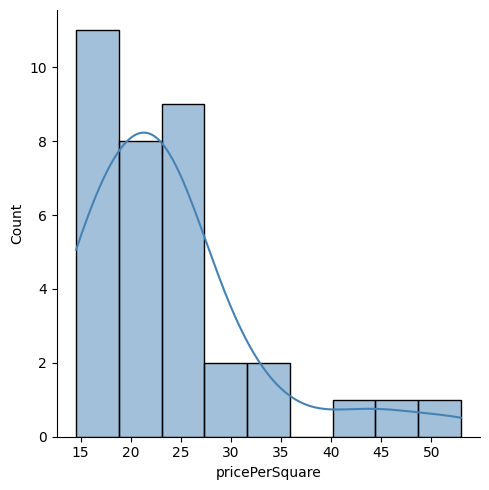

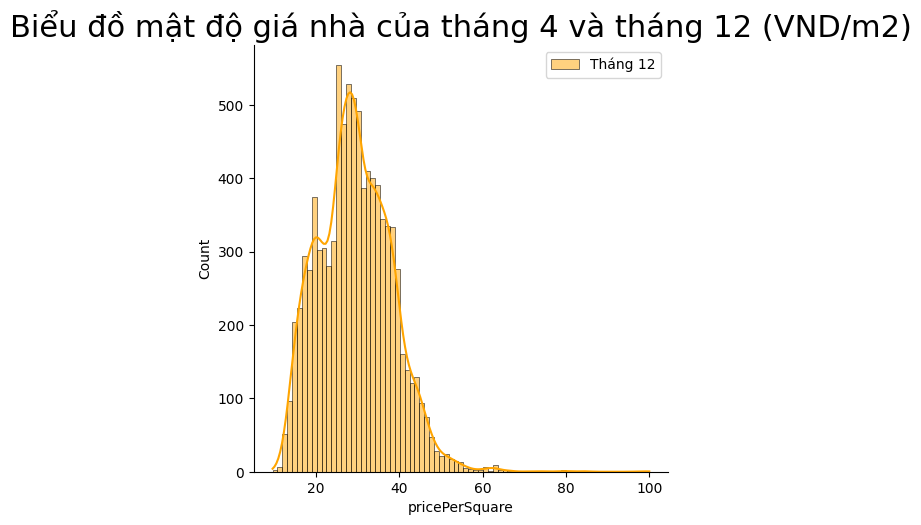

In [11]:
plt.figure(figsize=(13, 10), dpi=80)
sns.displot(dftmp[dftmp['month'] == '04']['pricePerSquare'], color='steelblue', label='Tháng 4', kde=True)
sns.displot(dftmp[dftmp['month'] == '12']['pricePerSquare'], color='orange', label='Tháng 12', kde=True)
plt.title("Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)", fontsize=22)
plt.legend()
plt.show()

* Số lượng bất động sản phân theo số lượng bedrooms

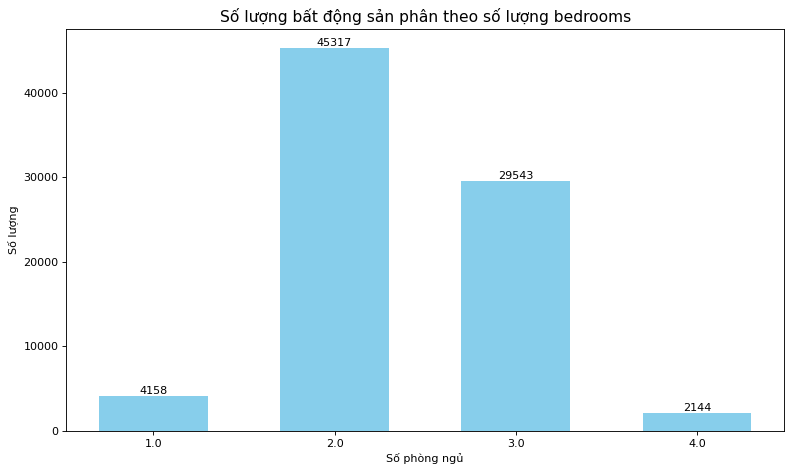

In [46]:
df_bedroom = dftmp.groupby('bedrooms').size().reset_index(name='count')
df_bedroom = df_bedroom.sort_values('bedrooms')
plt.figure(figsize=(10, 6), dpi=80)
plt.bar(df_bedroom['bedrooms'].astype(str), df_bedroom['count'], color='skyblue', width=.6)
for i, val in enumerate(df_bedroom['count'].values):
    plt.text(i, val, int(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':10})
plt.title("Số lượng bất động sản phân theo số lượng bedrooms", fontsize=14)
plt.xlabel('Số phòng ngủ')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

* Giá bất động sản trung bình theo số lượng bedrooms

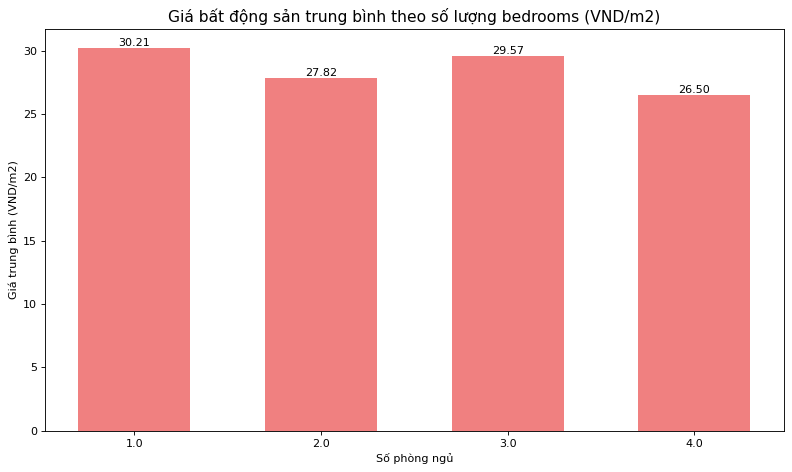

In [15]:
df_price_bedroom = dftmp.groupby('bedrooms')['pricePerSquare'].mean().reset_index(name='amount')
df_price_bedroom = df_price_bedroom.sort_values('bedrooms')
plt.figure(figsize=(10, 6), dpi=80)
plt.bar(df_price_bedroom['bedrooms'].astype(str), df_price_bedroom['amount'], color='lightcoral', width=.6)
for i, val in enumerate(df_price_bedroom['amount'].values):
    plt.text(i, val, f'{val:.2f}', horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':10})
plt.title("Giá bất động sản trung bình theo số lượng bedrooms (VND/m2)", fontsize=14)
plt.xlabel('Số phòng ngủ')
plt.ylabel('Giá trung bình (VND/m2)')
plt.tight_layout()
plt.show()

* Giá nhà đất trung bình theo quận (VND/m2)

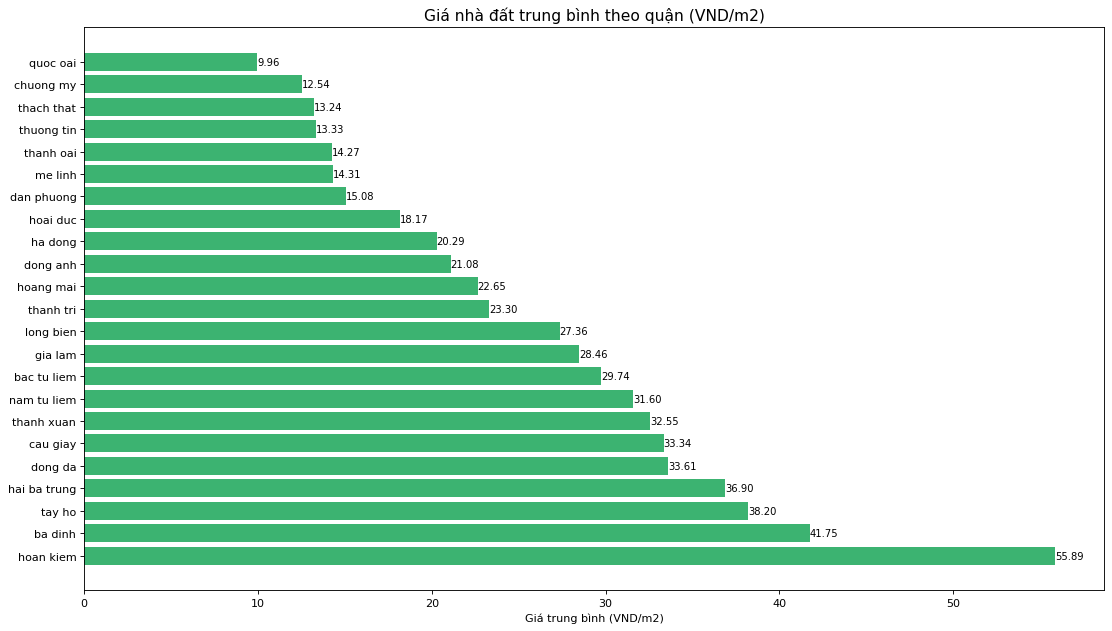

In [13]:
df_price_district = dftmp.groupby('district')['pricePerSquare'].mean().reset_index(name='price').sort_values('price', ascending=False)
plt.figure(figsize=(14, 8), dpi=80)
plt.barh(df_price_district['district'], df_price_district['price'], color='mediumseagreen')
for i, val in enumerate(df_price_district['price'].values):
    plt.text(val, i, f'{val:.2f}', verticalalignment='center', fontdict={'fontweight':500, 'size':9})
plt.title("Giá nhà đất trung bình theo quận (VND/m2)", fontsize=14)
plt.xlabel('Giá trung bình (VND/m2)')
plt.tight_layout()
plt.show()

* Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)

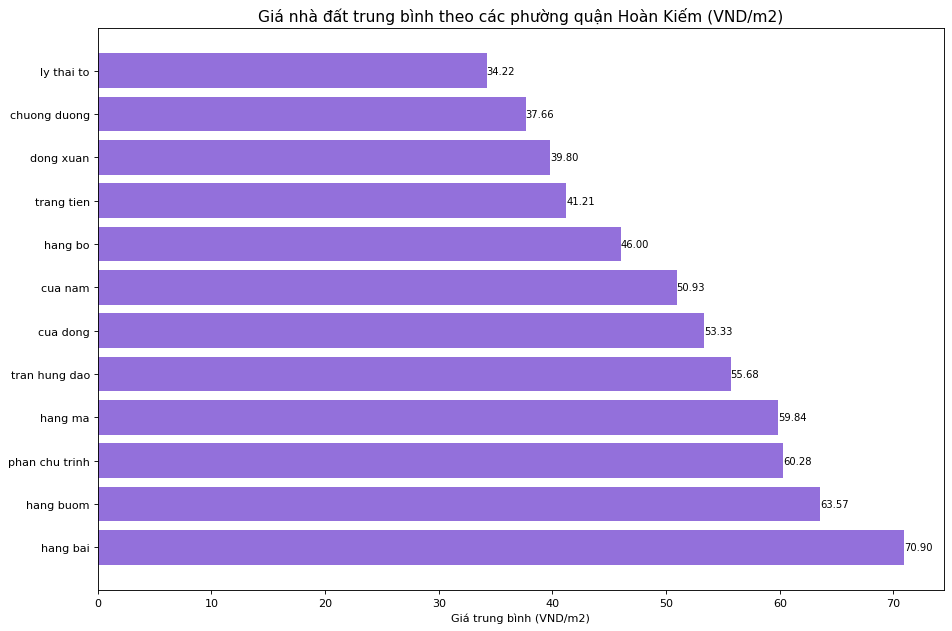

In [25]:
df_hoan_kiem = dftmp[dftmp['district'] == 'hoan kiem'].groupby('ward')['pricePerSquare'].mean().reset_index(name='price').sort_values('price', ascending=False)
plt.figure(figsize=(12, 8), dpi=80)
plt.barh(df_hoan_kiem['ward'], df_hoan_kiem['price'], color='mediumpurple')
for i, val in enumerate(df_hoan_kiem['price'].values):
    plt.text(val, i, f'{val:.2f}', verticalalignment='center', fontdict={'fontweight':500, 'size':9})
plt.title("Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)", fontsize=14)
plt.xlabel('Giá trung bình (VND/m2)')
plt.tight_layout()
plt.show()

* Giá nhà đất trung bình theo nhà đầu tư (VND/m2)

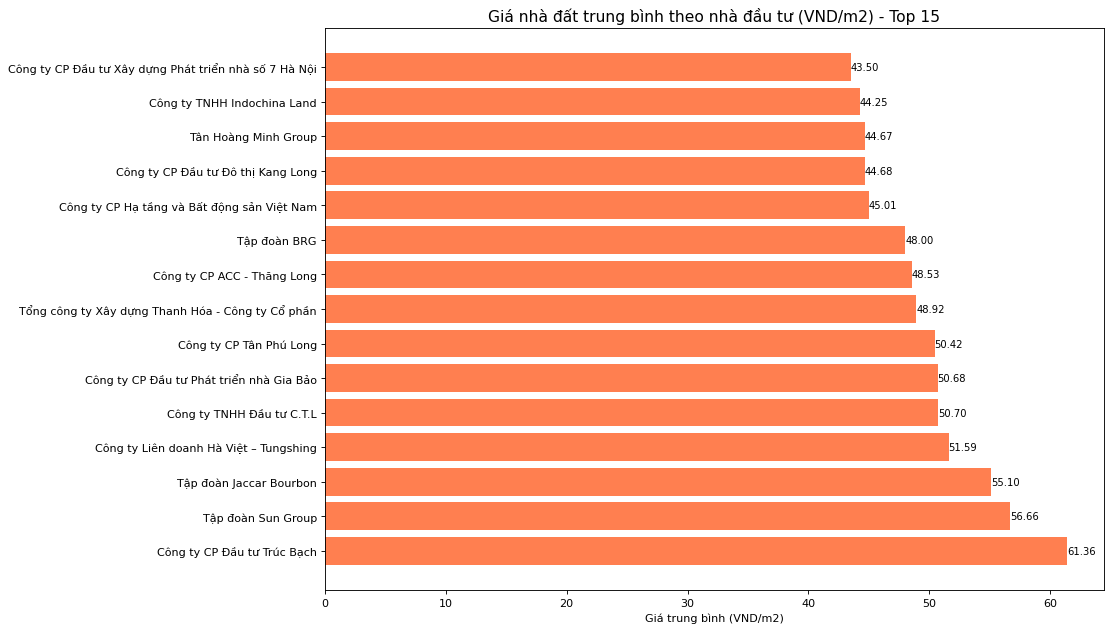

In [17]:
df_price_investor = dftmp.groupby('investor')['pricePerSquare'].mean().reset_index(name='price').sort_values('price', ascending=False).head(15)
plt.figure(figsize=(14, 8), dpi=80)
plt.barh(df_price_investor['investor'], df_price_investor['price'], color='coral')
for i, val in enumerate(df_price_investor['price'].values):
    plt.text(val, i, f'{val:.2f}', verticalalignment='center', fontdict={'fontweight':500, 'size':9})
plt.title("Giá nhà đất trung bình theo nhà đầu tư (VND/m2) - Top 15", fontsize=14)
plt.xlabel('Giá trung bình (VND/m2)')
plt.tight_layout()
plt.show()

* Giá nhà đất trung bình theo dự án (VND/m2)

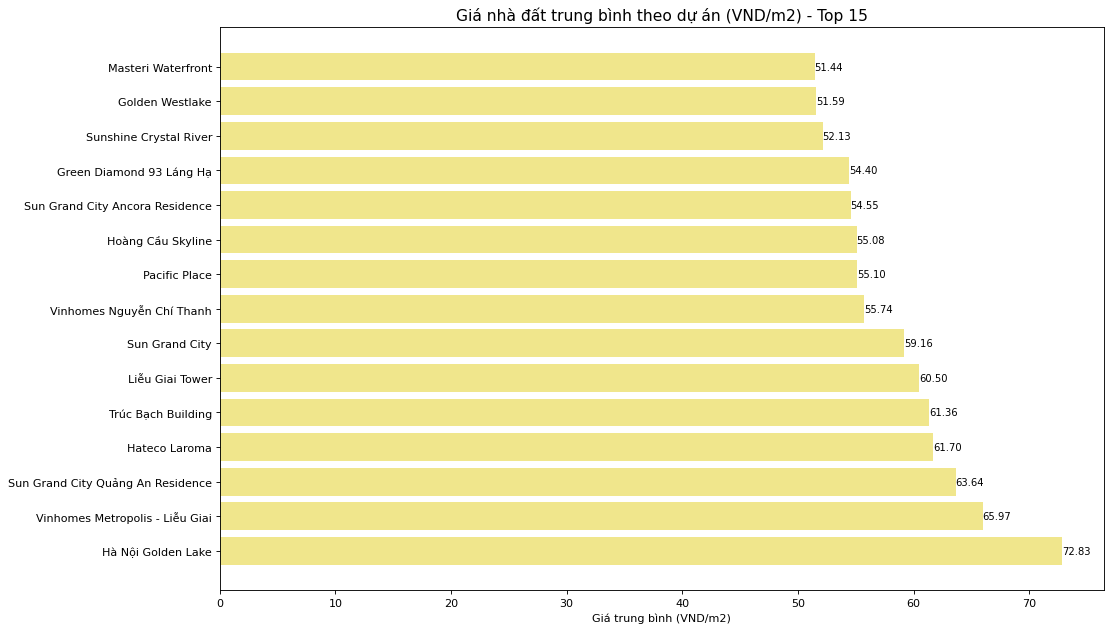

In [18]:
df_price_project = dftmp.groupby('project')['pricePerSquare'].mean().reset_index(name='price').sort_values('price', ascending=False).head(15)
plt.figure(figsize=(14, 8), dpi=80)
plt.barh(df_price_project['project'], df_price_project['price'], color='khaki')
for i, val in enumerate(df_price_project['price'].values):
    plt.text(val, i, f'{val:.2f}', verticalalignment='center', fontdict={'fontweight':500, 'size':9})
plt.title("Giá nhà đất trung bình theo dự án (VND/m2) - Top 15", fontsize=14)
plt.xlabel('Giá trung bình (VND/m2)')
plt.tight_layout()
plt.show()

* Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2

C:\Users\Admin\AppData\Local\Temp\ipykernel_10552\1563067738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_investor, x='investor', y='price', palette='Set2')
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\

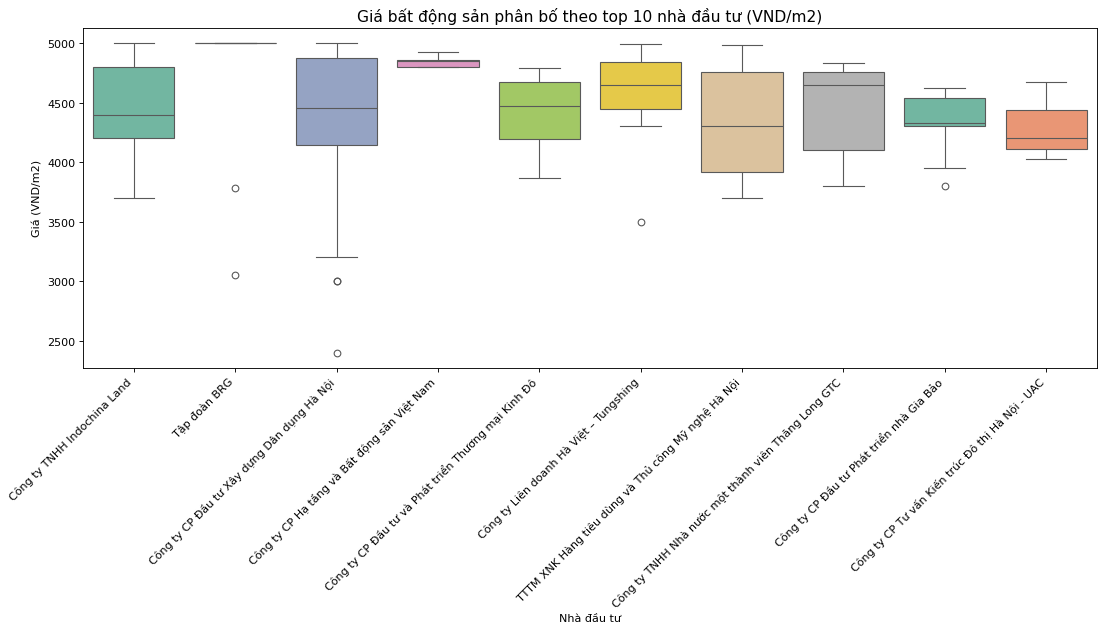

In [21]:
top_10_investor = newdf.groupby('investor')['price'].mean().nlargest(10).index.tolist()
df_top_investor = newdf[newdf['investor'].isin(top_10_investor)]
plt.figure(figsize=(14, 8), dpi=80)
sns.boxplot(data=df_top_investor, x='investor', y='price', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Giá bất động sản phân bố theo top 10 nhà đầu tư (VND/m2)", fontsize=14)
plt.ylabel('Giá (VND/m2)')
plt.xlabel('Nhà đầu tư')
plt.tight_layout()
plt.show()

* Giá bất động sản phân bố theo dự án

C:\Users\Admin\AppData\Local\Temp\ipykernel_10552\8329512.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_project, x='project', y='price', palette='Set1')
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\Admin

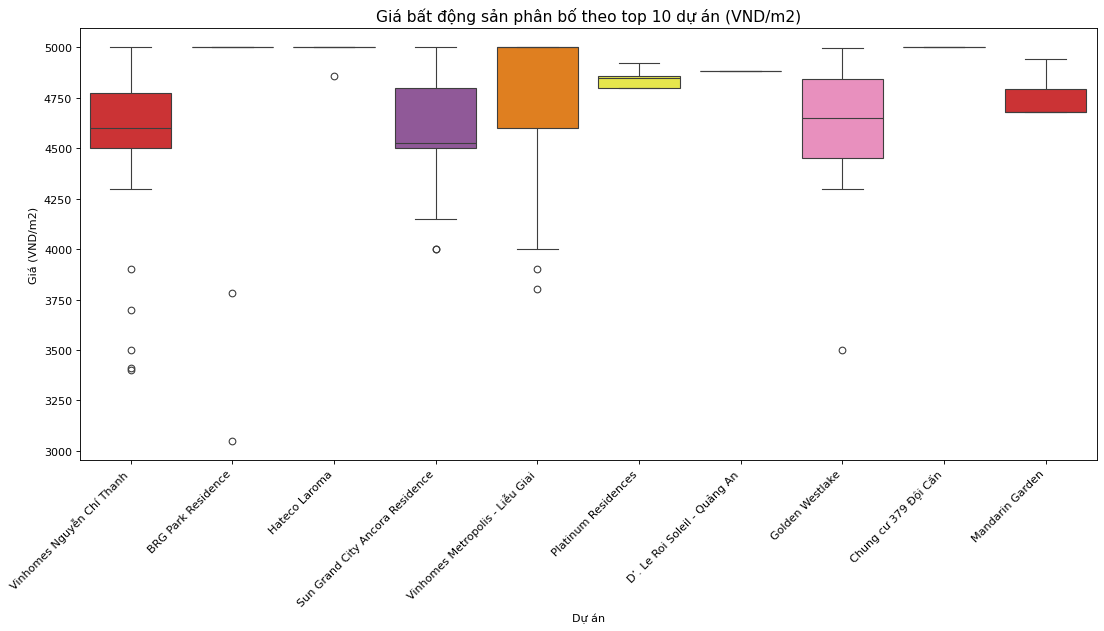

In [22]:
top_10_project = newdf.groupby('project')['price'].mean().nlargest(10).index.tolist()
df_top_project = newdf[newdf['project'].isin(top_10_project)]
plt.figure(figsize=(14, 8), dpi=80)
sns.boxplot(data=df_top_project, x='project', y='price', palette='Set1')
plt.xticks(rotation=45, ha='right')
plt.title("Giá bất động sản phân bố theo top 10 dự án (VND/m2)", fontsize=14)
plt.ylabel('Giá (VND/m2)')
plt.xlabel('Dự án')
plt.tight_layout()
plt.show()

* Giá nhà đất trung bình theo hướng nhà (VND/m2)

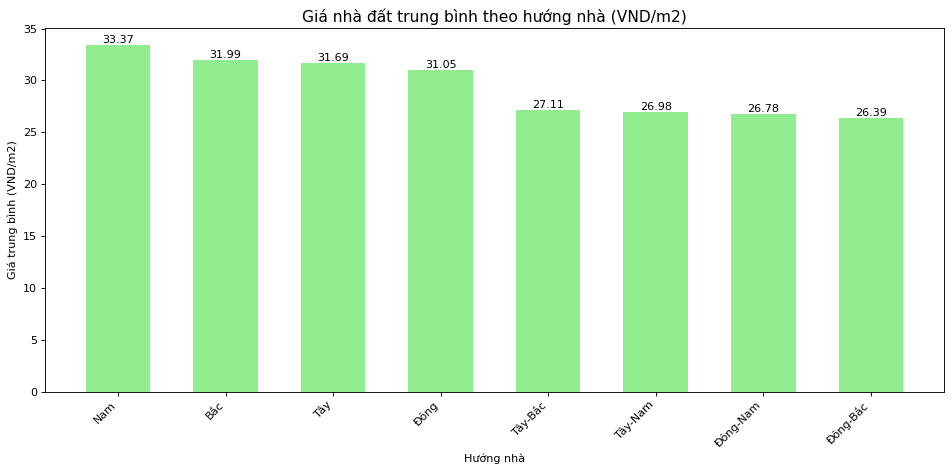

In [24]:
df_price_direction = dftmp.groupby('direction')['pricePerSquare'].mean().reset_index().sort_values('pricePerSquare', ascending=False)
plt.figure(figsize=(12, 6), dpi=80)
plt.bar(df_price_direction['direction'], df_price_direction['pricePerSquare'], color='lightgreen', width=.6)
for i, val in enumerate(df_price_direction['pricePerSquare'].values):
    plt.text(i, val, f'{val:.2f}', horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':10})
plt.xticks(rotation=45, ha='right')
plt.title("Giá nhà đất trung bình theo hướng nhà (VND/m2)", fontsize=14)
plt.ylabel('Giá trung bình (VND/m2)')
plt.xlabel('Hướng nhà')
plt.tight_layout()
plt.show()

3. Tương quan giữa các trường thuộc tính

* https://vi.wikipedia.org/wiki/H%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan
* bieu do the hien he so tuong quan giua cac cap bien so thuc banggf biểu đồ heatmap

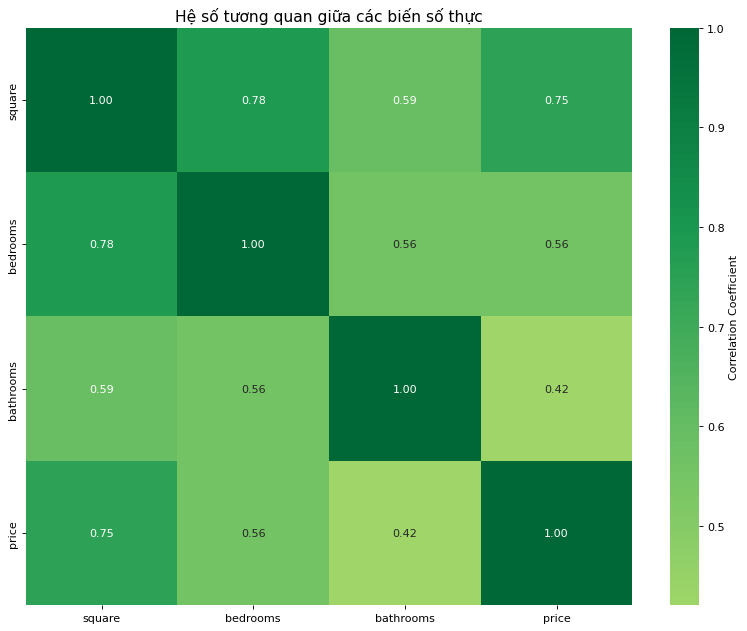

In [25]:
numeric_df = newdf.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8), dpi=80)
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Hệ số tương quan giữa các biến số thực', fontsize=14)
plt.tight_layout()
plt.show()

* bieu do the hien moi quan he giua cac bien so thuc với biểu đồ phân tán

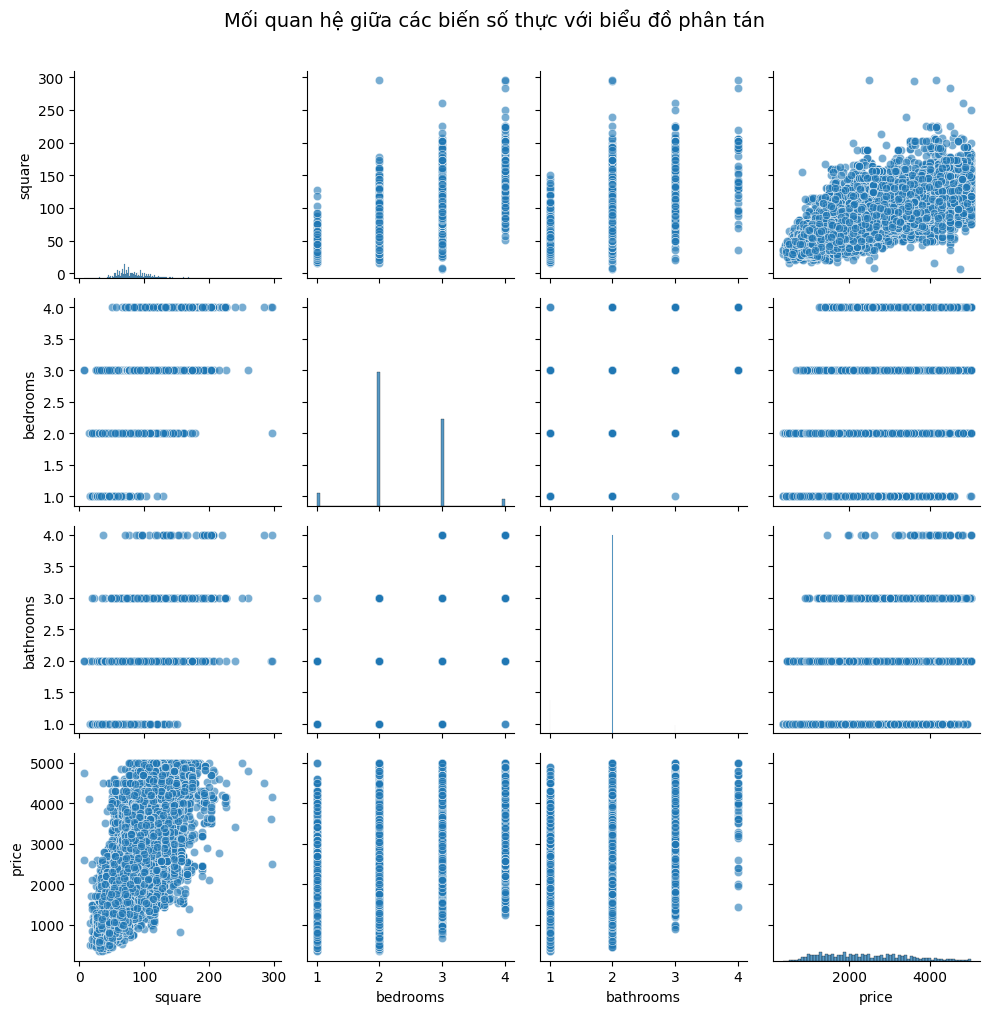

In [26]:
sns.pairplot(numeric_df, kind='scatter', diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Mối quan hệ giữa các biến số thực với biểu đồ phân tán', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

4. Mật độ giá nhà trung bình theo quận 

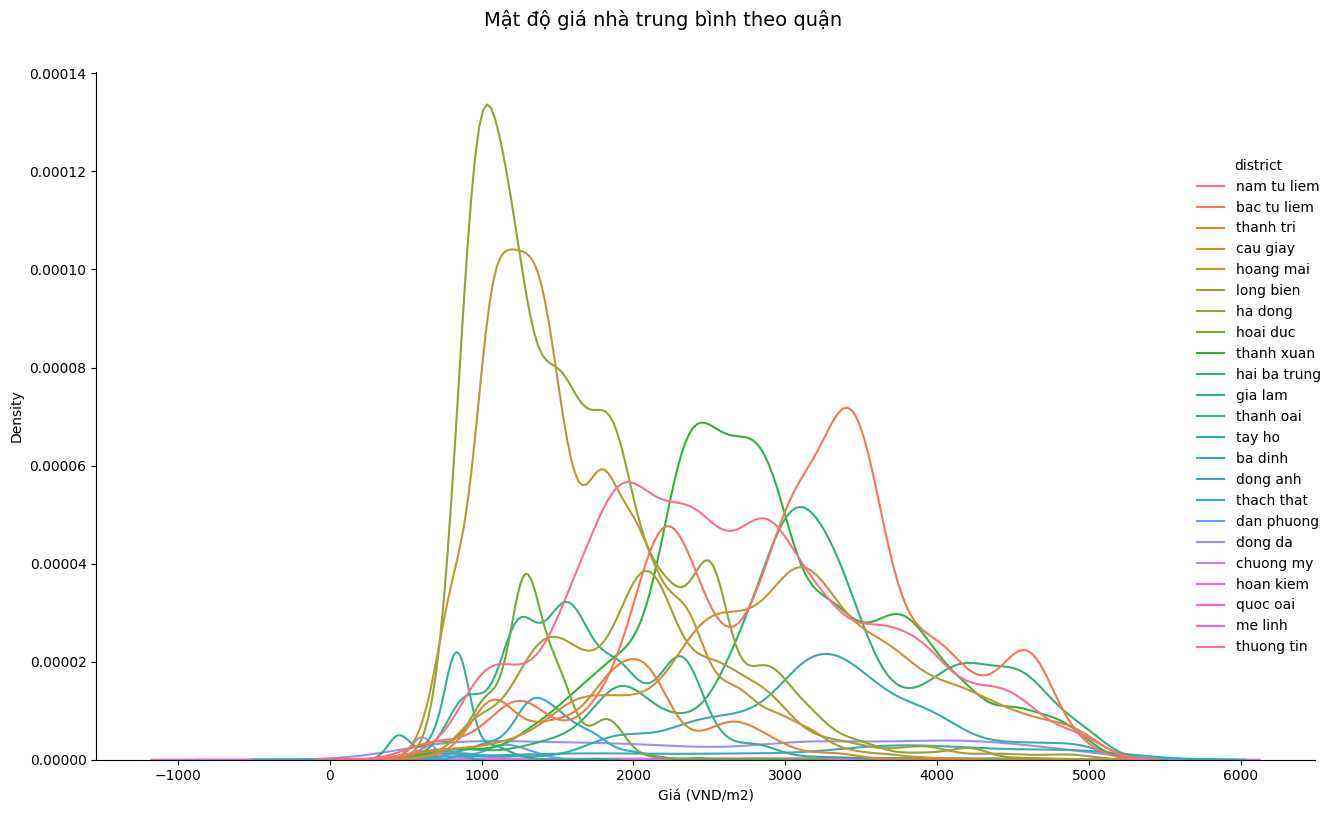

In [27]:
sns.displot(data=newdf, x='price', hue='district', kind='kde', height=8, aspect=1.5)
plt.suptitle('Mật độ giá nhà trung bình theo quận', fontsize=14, y=1.01)
plt.xlabel('Giá (VND/m2)')
plt.tight_layout()
plt.show()

End :))